# Flight Delay Prediction
## Random Over Sampling to Handle Imbalance in ArrDel15
- <strong>Environment Setup:</strong> import libraries and load the dataset
- <strong>Imbalanced Data Analysis:</strong> understanding how the dataset balance is restored using random under sampling
- <strong>Random Oversampling:</strong> or up-sampling is where the minority class observations are randomly duplicated to increase the influence on the machine learning algorithm
- <strong>Inference:</strong> understand how the model produces results and choosing the best classifier

## Environment Setup

In [1]:
# Pre-requisites
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Store the classifier models to save time
import joblib

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Classifiers from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

# Performance metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
# from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Imbalanced dataset helpers
from imblearn.over_sampling import RandomOverSampler

df = pd.read_csv("Data/flight_and_weather_encoded.csv", index_col=0)

## Dataset Without Handling Imbalance

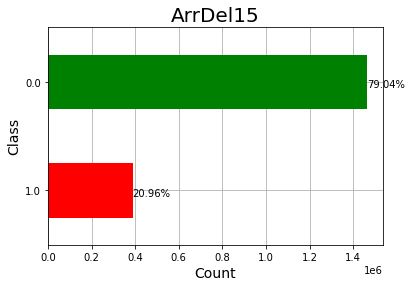

0.0    1463378
1.0     388058
Name: ArrDel15, dtype: int64


In [ ]:
# # Plotting the percentage of observations that fall under each class
# ax = df["ArrDel15"].value_counts().sort_values().plot(kind="barh", color=["r", "g"])
# ax.set_axisbelow(True)
# ax.grid()
# totals= []
# for i in ax.patches:
#     totals.append(i.get_width())
# total = sum(totals)
# for i in ax.patches:
#      ax.text(i.get_width()+.3, i.get_y()+.20, 
#      str(round((i.get_width()/total)*100, 2))+'%', 
#      fontsize=10, color='black')
# plt.title("ArrDel15", fontsize=20)
# plt.xlabel("Count", fontsize=14)
# plt.ylabel("Class", fontsize=14)
# plt.show()
# print(df["ArrDel15"].value_counts())
# fig = ax.get_figure()
# fig.savefig("Img/08_01_Dataset_ArrDel15_Class_Imbalance.png")

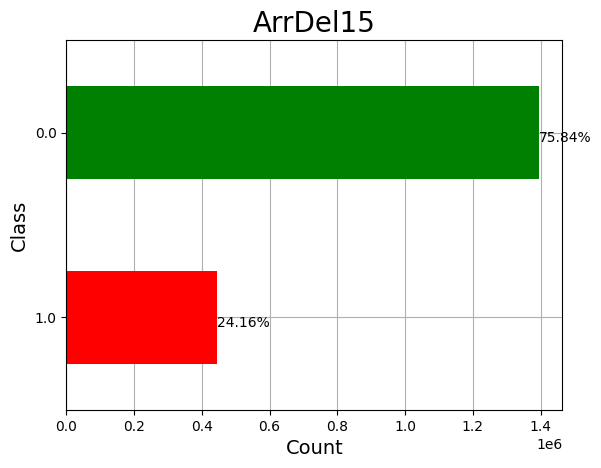

ArrDel15
0.0    1393948
1.0     443989
Name: count, dtype: int64


In [2]:
# Plotting the percentage of observations that fall under each class
ax = df["ArrDel15"].value_counts().sort_values().plot(kind="barh", color=["r", "g"])
ax.set_axisbelow(True)
ax.grid()
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
plt.title("ArrDel15", fontsize=20)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Class", fontsize=14)
plt.show()
print(df["ArrDel15"].value_counts())
fig = ax.get_figure()
fig.savefig("Img/08_01_Dataset_ArrDel15_Class_Imbalance.png")

In [ ]:
# features = df.loc[:, df.columns != "ArrDel15"]
# labels = np.asarray(df["ArrDel15"])
# # Number of samples/observations/rows is greater than 100,000
# print(f"\nDataset shape: {df.shape}")
# features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.20, random_state=42)
# print(f"features_train shape: {features_train.shape} | features_test shape: {features_test.shape}")
# print(f"labels_train shape: {labels_train.shape} | labels_test shape: {labels_test.shape}")
# # print(f"{features_train.shape[1]} Features: {features_train.columns.to_list()}")
# del features
# del labels


Dataset shape: (1851436, 24)
features_train shape: (1481148, 23) | features_test shape: (370288, 23)
labels_train shape: (1481148,) | labels_test shape: (370288,)


In [3]:
features = df.loc[:, df.columns != "ArrDel15"]
labels = np.asarray(df["ArrDel15"])
# Number of samples/observations/rows is greater than 100,000
print(f"\nDataset shape: {df.shape}")
features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.20, random_state=42)
print(f"features_train shape: {features_train.shape} | features_test shape: {features_test.shape}")
print(f"labels_train shape: {labels_train.shape} | labels_test shape: {labels_test.shape}")
# print(f"{features_train.shape[1]} Features: {features_train.columns.to_list()}")
del features
del labels


Dataset shape: (1837937, 24)
features_train shape: (1470349, 23) | features_test shape: (367588, 23)
labels_train shape: (1470349,) | labels_test shape: (367588,)


## Training Data Without Handling Imbalance

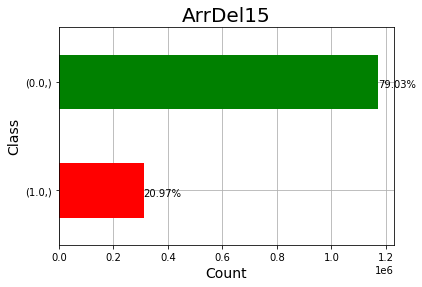

0.0    1170484
1.0     310664
dtype: int64


In [ ]:
# # Plotting the percentage of observations that fall under each class
# ax = pd.DataFrame(labels_train).value_counts().sort_values().plot(kind="barh", color=["r", "g"])
# ax.set_axisbelow(True)
# ax.grid()
# totals= []
# for i in ax.patches:
#     totals.append(i.get_width())
# total = sum(totals)
# for i in ax.patches:
#      ax.text(i.get_width()+.3, i.get_y()+.20, 
#      str(round((i.get_width()/total)*100, 2))+'%', 
#      fontsize=10, color='black')
# plt.title("ArrDel15", fontsize=20)
# plt.xlabel("Count", fontsize=14)
# plt.ylabel("Class", fontsize=14)
# plt.show()
# print(pd.DataFrame(labels_train).value_counts())
# fig = ax.get_figure()
# fig.savefig("Img/08_02_Training_ArrDel15_Class_Imbalance.png")

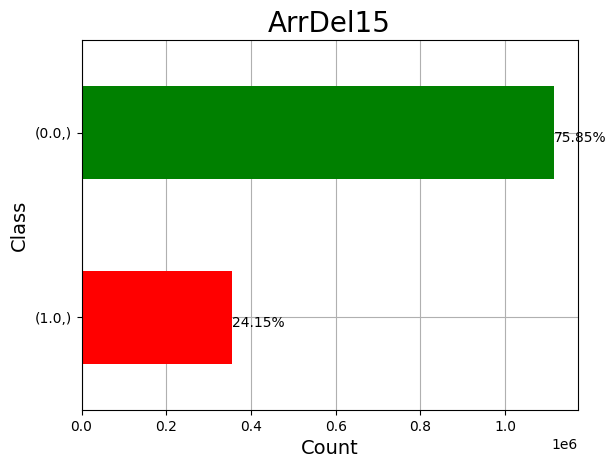

0  
0.0    1115249
1.0     355100
Name: count, dtype: int64


In [4]:
# Plotting the percentage of observations that fall under each class
ax = pd.DataFrame(labels_train).value_counts().sort_values().plot(kind="barh", color=["r", "g"])
ax.set_axisbelow(True)
ax.grid()
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
plt.title("ArrDel15", fontsize=20)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Class", fontsize=14)
plt.show()
print(pd.DataFrame(labels_train).value_counts())
fig = ax.get_figure()
fig.savefig("Img/08_02_Training_ArrDel15_Class_Imbalance.png")

## Random Oversampling

In [5]:
ros = RandomOverSampler(random_state=42)
features_train, labels_train = ros.fit_resample(features_train, labels_train)

### Balancing the Training Data

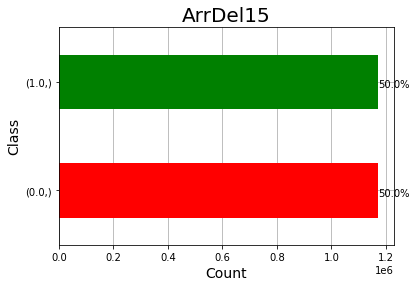

0.0    1170484
1.0    1170484
dtype: int64


In [ ]:
# # Plotting the percentage of observations that fall under each class
# ax = pd.DataFrame(labels_train).value_counts().sort_values().plot(kind="barh", color=["r", "g"])
# ax.set_axisbelow(True)
# ax.grid()
# totals= []
# for i in ax.patches:
#     totals.append(i.get_width())
# total = sum(totals)
# for i in ax.patches:
#      ax.text(i.get_width()+.3, i.get_y()+.20, 
#      str(round((i.get_width()/total)*100, 2))+'%', 
#      fontsize=10, color='black')
# plt.title("ArrDel15", fontsize=20)
# plt.xlabel("Count", fontsize=14)
# plt.ylabel("Class", fontsize=14)
# plt.show()
# print(pd.DataFrame(labels_train).value_counts())
# fig = ax.get_figure()
# fig.savefig("Img/08_03_RandomOverSampling_Training_ArrDel15_Class.png")

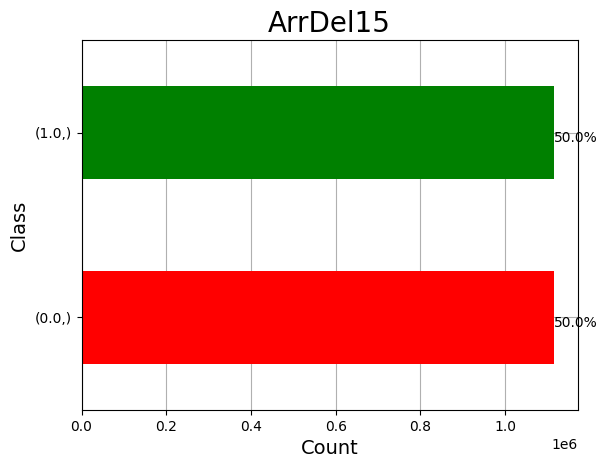

0  
0.0    1115249
1.0    1115249
Name: count, dtype: int64


In [5]:
# Plotting the percentage of observations that fall under each class
ax = pd.DataFrame(labels_train).value_counts().sort_values().plot(kind="barh", color=["r", "g"])
ax.set_axisbelow(True)
ax.grid()
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
plt.title("ArrDel15", fontsize=20)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Class", fontsize=14)
plt.show()
print(pd.DataFrame(labels_train).value_counts())
fig = ax.get_figure()
fig.savefig("Img/08_03_RandomOverSampling_Training_ArrDel15_Class.png")

### Logistic Regression

              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93    292894
         1.0       0.74      0.78      0.76     77394

    accuracy                           0.90    370288
   macro avg       0.84      0.85      0.85    370288
weighted avg       0.90      0.90      0.90    370288



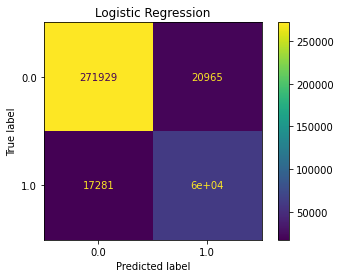

In [ ]:
# # model = LogisticRegression(n_jobs=-1)
# # model.fit(features_train, labels_train)
# # joblib.dump(model, "./RandomOverSampling/LogisticRegression.joblib")
# model = joblib.load("./RandomOverSampling/LogisticRegression.joblib")
# model_pred = model.predict(features_test)
# # print(confusion_matrix(labels_test, model_pred))
# print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
# plt.title("Logistic Regression")
# print(conf_mat_plot)
# plt.savefig("Img/08_04_RandomOverSampling_LR_Confusion_Matrix")
# del model
# del model_pred

              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93    278699
         1.0       0.77      0.79      0.78     88889

    accuracy                           0.89    367588
   macro avg       0.85      0.86      0.86    367588
weighted avg       0.89      0.89      0.89    367588



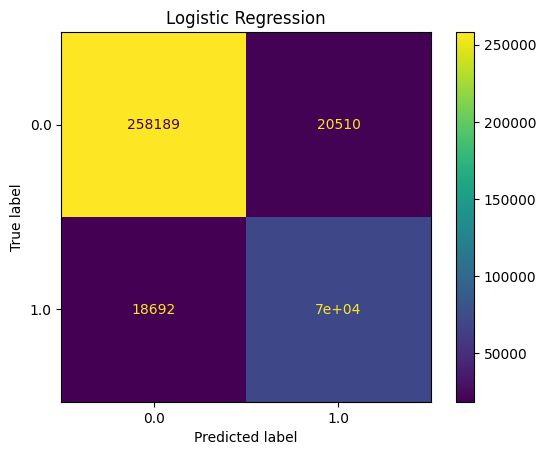

In [9]:
# model = LogisticRegression(n_jobs=-1)
# model.fit(features_train, labels_train)
# joblib.dump(model, "./RandomOverSampling/LogisticRegression.joblib")
model = joblib.load("./RandomOverSampling/LogisticRegression.joblib")
model_pred = model.predict(features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, features_test, labels_test)

plt.title("Logistic Regression")
print(conf_mat_plot)
plt.savefig("Img/08_04_RandomOverSampling_LR_Confusion_Matrix")
del model
del model_pred

### Decision Tree Classifier

              precision    recall  f1-score   support

         0.0       0.92      0.92      0.92    292894
         1.0       0.69      0.70      0.70     77394

    accuracy                           0.87    370288
   macro avg       0.81      0.81      0.81    370288
weighted avg       0.87      0.87      0.87    370288



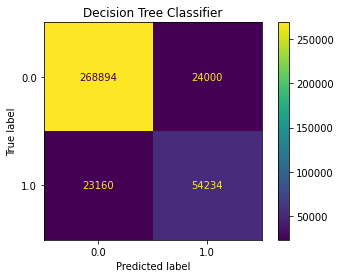

In [ ]:
# # model = DecisionTreeClassifier()
# # model.fit(features_train, labels_train)
# # joblib.dump(model, "./RandomOverSampling/DecisionTreeClassifier.joblib")
# model = joblib.load("./RandomOverSampling/DecisionTreeClassifier.joblib")
# model_pred = model.predict(features_test)
# # print(confusion_matrix(labels_test, model_pred))
# print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
# plt.title("Decision Tree Classifier")
# print(conf_mat_plot)
# plt.savefig("Img/08_05_RandomOverSampling_DTC_Confusion_Matrix")
# del model
# del model_pred

              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91    278699
         1.0       0.71      0.72      0.72     88889

    accuracy                           0.86    367588
   macro avg       0.81      0.81      0.81    367588
weighted avg       0.86      0.86      0.86    367588



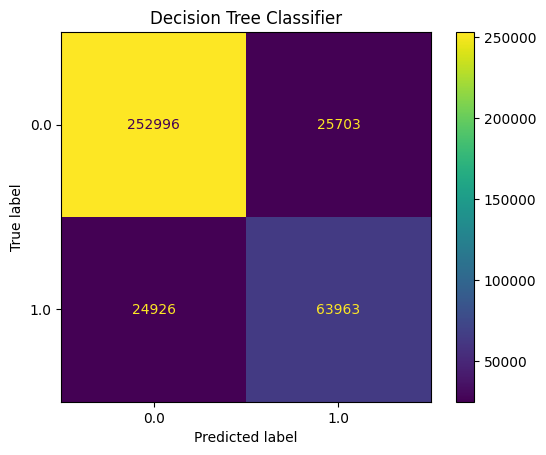

In [11]:
# model = DecisionTreeClassifier()
# model.fit(features_train, labels_train)
# joblib.dump(model, "./RandomOverSampling/DecisionTreeClassifier.joblib")
model = joblib.load("./RandomOverSampling/DecisionTreeClassifier.joblib")
model_pred = model.predict(features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, features_test, labels_test)

plt.title("Decision Tree Classifier")
print(conf_mat_plot)
plt.savefig("Img/08_05_RandomOverSampling_DTC_Confusion_Matrix")
del model
del model_pred

### Gradient Boosting Classifier

              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93    292894
         1.0       0.73      0.79      0.76     77394

    accuracy                           0.90    370288
   macro avg       0.84      0.86      0.85    370288
weighted avg       0.90      0.90      0.90    370288



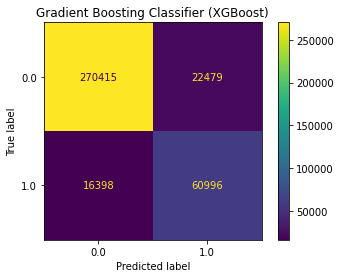

In [ ]:
# # model = GradientBoostingClassifier()
# # model.fit(features_train, labels_train)
# # joblib.dump(model, "./RandomOverSampling/GradientBoostingClassifier.joblib")
# model = joblib.load("./RandomOverSampling/GradientBoostingClassifier.joblib")
# model_pred = model.predict(features_test)
# # print(confusion_matrix(labels_test, model_pred))
# print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
# plt.title("Gradient Boosting Classifier (XGBoost)")
# print(conf_mat_plot)
# plt.savefig("Img/08_06_RandomOverSampling_GBC_Confusion_Matrix")
# del model
# del model_pred

              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93    278699
         1.0       0.77      0.79      0.78     88889

    accuracy                           0.89    367588
   macro avg       0.85      0.86      0.86    367588
weighted avg       0.89      0.89      0.89    367588



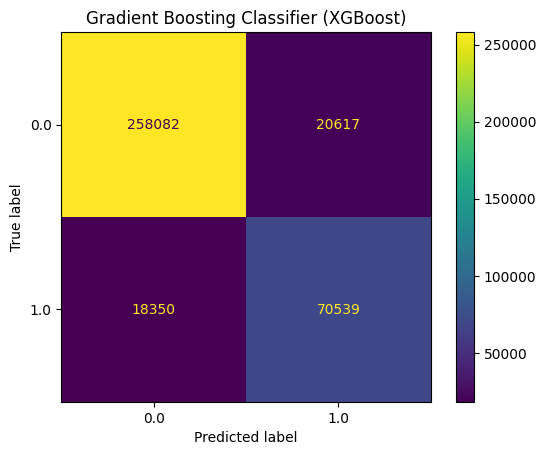

In [13]:
# model = GradientBoostingClassifier()
# model.fit(features_train, labels_train)
# joblib.dump(model, "./RandomOverSampling/GradientBoostingClassifier.joblib")
model = joblib.load("./RandomOverSampling/GradientBoostingClassifier.joblib")
model_pred = model.predict(features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, features_test, labels_test)
plt.title("Gradient Boosting Classifier (XGBoost)")
print(conf_mat_plot)
plt.savefig("Img/08_06_RandomOverSampling_GBC_Confusion_Matrix")
del model
del model_pred

### Random Forest

              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94    292894
         1.0       0.82      0.74      0.78     77394

    accuracy                           0.91    370288
   macro avg       0.88      0.85      0.86    370288
weighted avg       0.91      0.91      0.91    370288



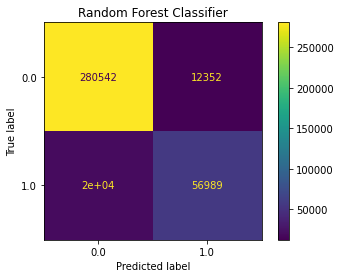

In [ ]:
# # model = RandomForestClassifier(n_jobs=-1)
# # model.fit(features_train, labels_train)
# # joblib.dump(model, "./RandomOverSampling/RandomForestClassifier.joblib")
# model = joblib.load("./RandomOverSampling/RandomForestClassifier.joblib")
# model_pred = model.predict(features_test)
# # print(confusion_matrix(labels_test, model_pred))
# print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
# plt.title("Random Forest Classifier")
# print(conf_mat_plot)
# plt.savefig("Img/08_07_RandomOverSampling_RFC_Confusion_Matrix")
# del model
# del model_pred

              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94    278699
         1.0       0.83      0.76      0.79     88889

    accuracy                           0.90    367588
   macro avg       0.88      0.85      0.86    367588
weighted avg       0.90      0.90      0.90    367588



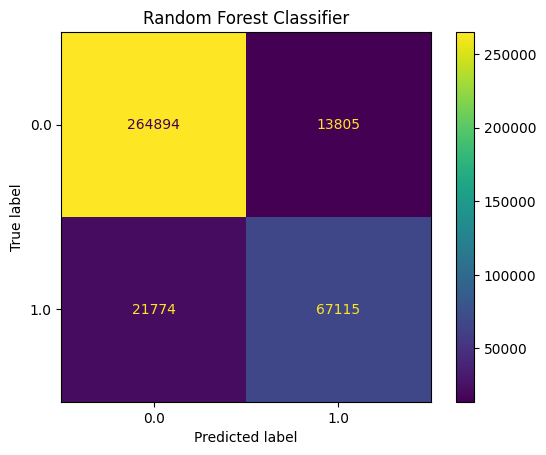

In [15]:
# model = RandomForestClassifier(n_jobs=-1)
# model.fit(features_train, labels_train)
# joblib.dump(model, "./RandomOverSampling/RandomForestClassifier.joblib")
model = joblib.load("./RandomOverSampling/RandomForestClassifier.joblib")
model_pred = model.predict(features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, features_test, labels_test)
plt.title("Random Forest Classifier")
print(conf_mat_plot)
plt.savefig("Img/08_07_RandomOverSampling_RFC_Confusion_Matrix")
del model
del model_pred

### Extra Trees Classifier

              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94    292894
         1.0       0.82      0.73      0.77     77394

    accuracy                           0.91    370288
   macro avg       0.87      0.84      0.86    370288
weighted avg       0.91      0.91      0.91    370288



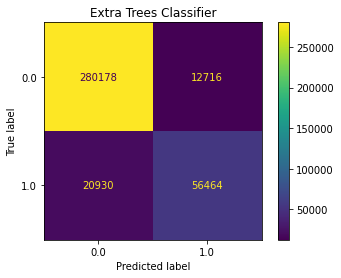

In [ ]:
# model = ExtraTreesClassifier(n_jobs=-1)
# model.fit(features_train, labels_train)
# # joblib.dump(model, "./RandomOverSampling/ExtraTreesClassifier.joblib")
# # model = joblib.load("./RandomOverSampling/ExtraTreesClassifier.joblib")
# model_pred = model.predict(features_test)
# # print(confusion_matrix(labels_test, model_pred))
# print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
# plt.title("Extra Trees Classifier")
# print(conf_mat_plot)
# plt.savefig("Img/08_08_RandomOverSampling_ETC_Confusion_Matrix")

              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93    278699
         1.0       0.82      0.75      0.78     88889

    accuracy                           0.90    367588
   macro avg       0.87      0.85      0.86    367588
weighted avg       0.90      0.90      0.90    367588



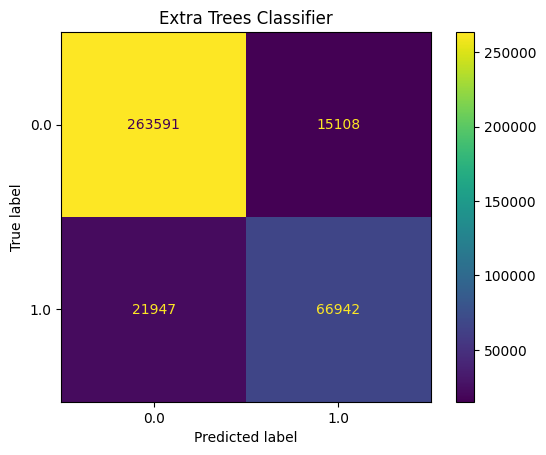

In [6]:
# model = ExtraTreesClassifier(n_jobs=-1)
# model.fit(features_train, labels_train)
# joblib.dump(model, "./RandomOverSampling/ExtraTreesClassifier.joblib")
model = joblib.load("./RandomOverSampling/ExtraTreesClassifier.joblib")
model_pred = model.predict(features_test)
# print(confusion_matrix(labels_test, model_pred))
print(classification_report(labels_test, model_pred))
# conf_mat_plot = plot_confusion_matrix(model, features_test, labels_test)
conf_mat_plot = ConfusionMatrixDisplay.from_estimator(model, features_test, labels_test)

plt.title("Extra Trees Classifier")
print(conf_mat_plot)
plt.savefig("Img/08_08_RandomOverSampling_ETC_Confusion_Matrix")

## Inference
<table>
    <thead>
        <tr>
            <th rowspan="3">Classification Model</th>
            <th colspan="8">Performance Metric</th>
        </tr>
        <tr>
            <th colspan="2">Precision</th>
            <th colspan="2">Recall</th>
            <th colspan="2">F1 Score</th>
            <th rowspan="2" colspan="2">Accuracy</th>
        </tr>
        <tr>
            <th>0.0</th>
            <th>1.0</th>
            <th>0.0</th>
            <th>1.0</th>
            <th>0.0</th>
            <th>1.0</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <th>Logistic Regression</th>
            <td>0.94</td>
            <td>0.74</td>
            <td>0.93</td>
            <td>0.78</td>
            <td>0.93</td>
            <td>0.76</td>
            <td>0.90</td>
        </tr>
        <tr>
            <th>Decision Tree Classifier</th>
            <td>0.92</td>
            <td>0.69</td>
            <td>0.92</td>
            <td>0.70</td>
            <td>0.92</td>
            <td>0.70</td>
            <td>0.87</td>
        </tr>
        <tr>
            <th>Extra Trees Classifier</th>
            <td>0.93</td>
            <td>0.82</td>
            <td>0.96</td>
            <td>0.73</td>
            <td>0.94</td>
            <td>0.77</td>
            <td>0.91</td>
        </tr>
        <tr>
            <th>Gradient Boosting Classifier</th>
            <td>0.94</td>
            <td>0.73</td>
            <td>0.92</td>
            <td>0.79</td>
            <td>0.93</td>
            <td>0.76</td>
            <td>0.90</td>
        </tr>
        <tr>
            <th>Random Forest Classifier</th>
            <td>0.93</td>
            <td>0.82</td>
            <td>0.96</td>
            <td>0.74</td>
            <td>0.94</td>
            <td>0.78</td>
            <td>0.91</td>
        </tr>
    </tbody>
</table>